In [11]:
from IPython.display import Image

- abilities & novelty
    - 实用，且有新意
- Visual Prompting：从早期的 object localization trick 变成辅助空间视觉推理工具，
    - 直接生成坐标 => 选择题；
        - regression => classification
    - 辅助定位，降低推理的难度；
    - 帮助模型focus以稳定注意力；

### What's Visual prompting

- sam1 -> sam2 -> sam3
    - sam1/2: instance-level seg, point/bbox
        - SAM 2 also supports automatic mask generation on images just like SAM.
            - https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb
            - https://github.com/facebookresearch/sam2/blob/main/notebooks/automatic_mask_generator_example.ipynb
    - sam3: promptable concept segmentation, point/bbox + text prompt (noun phrase) / exemplar (示例图, positive/negative)
        - https://www.bilibili.com/video/BV1yyqqBBEqB/
        - sam3 agent: vlm + sam3
            - `the leftmost child wearing blue vest"` => `child in blue vest` (masked image) => vlm
- https://aws.amazon.com/blogs/machine-learning/foundational-vision-models-and-visual-prompt-engineering-for-autonomous-driving-applications/
- https://github.com/IDEA-Research/Grounded-SAM-2
    - Grounding SAM2 = Grouding DINO + SAM2

In [13]:
Image(url='./figs/g_sam2_tracking_pipeline_vis_new.png', width=600)

### SoM: Set-of-Mark Prompting Unleashes  Extraordinary Visual Grounding in GPT-4V

- for object localization tasks
- 将图像分割为语义区域，赋予每个区域可读的“ID”，让 vlm "看图说话"。
    - $I^o=\mathcal F(I, T^i)\rightarrow I^o=\mathcal F(\text{SoM}(I), T^i)$
    - partition tool + mark types
- "Training Data" Hypothesis（SoM）：
    - In the "Discussion" section, the authors hypothesize that GPT-4V likely performs exceptionally well with SoM because its training data likely included many labeled figures, charts, and textbooks where text labels are naturally associated with image regions. This makes the model pre-conditioned to understand images with overlaid symbolic marks.

### FreeGrasp: Free-form language-based robotic reasoning and grasping

- Molmo: 获取中心点坐标 (Object Localization)
    - "Point out all objects in the bin"
    - "typically around the centers of the corresponding objects"
- Mark-based Visual Prompting
    - 系统获得这些 2D 坐标后，会给每个物体分配一个唯一的数字 ID。然后，系统会在原始 RGB 图像上的这些 2D 坐标位置处，绘制带有数字的标记（numbered markers）。

- Structured Prompting: Vision-language grasp reasoning
```
You are a robotic system for bin picking, using a parallel gripper. I labeled all objects id in the image. (...) 
Given a target object description as input, determine the first object that needs to be grasped to enable picking the target object. If the target object is free of obstacles, return the target object ID itself. Otherwise, identify an object that is occluding the target and is itself free of obstacles. If multiple objects could be removed, return any one valid option. The output should only be the object ID of the first object to grasp, must formatted as [object_id, color class_name].
```

### PIVOT:  Iterative Visual Prompting Elicits Actionable Knowledge for VLMs

* **输入**:
    * $I$: 原始 RGB 图像。
    * $l$: 自然语言指令（例如：“Pick up the red block”）。
    * $\mathcal{A}$: 连续动作空间（例如末端执行器的 $\Delta x, \Delta y, \Delta z$）。
* **映射函数 $\Omega$**:
    * 将物理动作 $a$ 投影到图像平面，生成标注图 $\hat{I}$ 和文本标签 $w$。
    * $(\hat{I}, w_{1:M}) = \Omega(I, a_{1:M})$
* **优化目标**:
    * 寻找动作 $a$，使得 VLM 选择其对应标签 $w$ 的概率最大化：
    * $\max_{a \in \mathcal{A}} P_{VLM}(w | \hat{I}, l) \quad \text{s.t.} \quad (\hat{I}, w) = \Omega(I, a)$

In [9]:
Image(url='./figs/pivot-algo.png', width=500)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

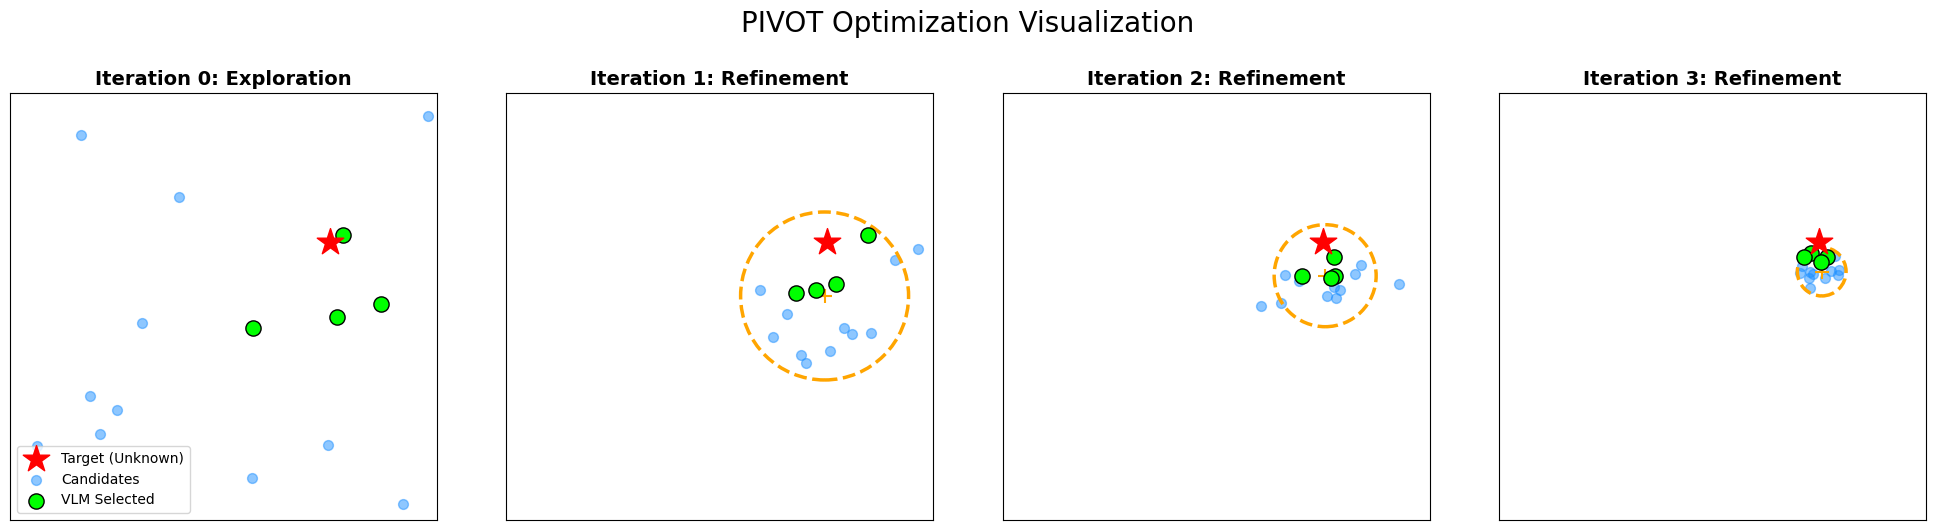

In [5]:
# --- 1. 设置实验环境 ---
# 假设目标点（Ground Truth），只有 VLM (Oracle) 知道这个位置
target = np.array([0.75, 0.65]) 

n_iterations = 4      # 迭代轮数
n_samples = 15        # 每轮采样的候选动作数 (M)
n_elites = 4          # VLM 选出的优胜者数量 (Top-K)

# 创建画布
fig, axes = plt.subplots(1, n_iterations, figsize=(20, 5))

# 初始化分布参数 (用于 Iteration > 0)
current_mu = None
current_cov = None

# --- 2. 开始迭代循环 ---
for i in range(n_iterations):
    ax = axes[i]
    
    # [Step A: 采样]
    if i == 0:
        # 第 0 轮：在整个空间均匀采样 (Uniform Sampling)
        # 模拟初始状态，机器人不知道去哪，随机撒点
        samples = np.random.rand(n_samples, 2)
        title_dist = "Iteration 0: Exploration"
    else:
        # 后续轮次：从高斯分布采样 (Gaussian Sampling)
        # 模拟根据上一轮的建议，在重点区域撒点
        samples = np.random.multivariate_normal(current_mu, current_cov, n_samples)
        samples = np.clip(samples, 0, 1) # 限制在视野范围内
        title_dist = f"Iteration {i}: Refinement"

    # [Step B: VLM 选择] (Oracle Simulation)
    # 模拟 VLM 的视觉评估能力：VLM 会指出离目标物体最近的几个点
    # 我们通过计算欧氏距离来模拟这一过程
    distances = np.linalg.norm(samples - target, axis=1)
    elite_indices = np.argsort(distances)[:n_elites] # 选出距离最小的 K 个
    elites = samples[elite_indices]
    
    # [Step C: 分布拟合]
    # 计算优胜点的中心 (Mean)
    new_mu = np.mean(elites, axis=0)
    
    # 计算优胜点的分散程度 (Isotropic Covariance)
    # PIVOT 使用各向同性高斯，即假设 X 和 Y 方向方差相同，简化计算
    variance = np.mean(np.var(elites, axis=0)) + 1e-4 # 加极小值防止方差为0
    new_cov = np.eye(2) * variance
    
    # --- 3. 可视化绘制 ---
    
    # 绘制目标 (红星)
    ax.scatter(target[0], target[1], c='red', marker='*', s=400, label='Target (Unknown)', zorder=10)
    
    # 绘制所有采样点 (蓝点)
    ax.scatter(samples[:, 0], samples[:, 1], c='dodgerblue', alpha=0.5, s=50, label='Candidates')
    
    # 高亮 VLM 选中的点 (绿点)
    ax.scatter(elites[:, 0], elites[:, 1], c='lime', edgecolors='black', s=120, label='VLM Selected', zorder=5)
    
    # 绘制搜索范围 (橙色虚线圈)
    if i > 0:
        # 画出 2倍标准差范围，代表当前的搜索热区
        std_dev = np.sqrt(current_cov[0, 0])
        ellipse = Ellipse(xy=current_mu, width=4*std_dev, height=4*std_dev, 
                          edgecolor='orange', fc='None', lw=2.5, linestyle='--', label='Search Region')
        ax.add_patch(ellipse)
        # 标记上一轮的中心
        ax.scatter(current_mu[0], current_mu[1], c='orange', marker='+', s=100)

    # 图表格式设置
    ax.set_title(title_dist, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
    
    # 只在第一张图显示图例
    if i == 0:
        ax.legend(loc='lower left', frameon=True, fontsize=10)
    
    # [Step D: 更新参数]
    # 将拟合好的新分布用于下一轮采样
    current_mu = new_mu
    current_cov = new_cov

plt.suptitle("PIVOT Optimization Visualization", fontsize=20, y=1.05)
plt.tight_layout()